In [ ]:
!pip install smogn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import smogn
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
placement = pd.read_csv("/content/Placement_Prediction_data.csv")
salary = pd.read_csv("/content/Salary_prediction_data.csv")


In [ ]:
placement.head()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced
1,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed
2,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced
3,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed
4,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed


In [ ]:
salary.head()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus,salary
0,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced,0
1,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed,1000000
2,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced,0
3,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed,950000
4,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed,950000


In [ ]:
placement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CGPA                        10000 non-null  float64
 1   Major Projects              10000 non-null  int64  
 2   Workshops/Certificatios     10000 non-null  int64  
 3   Mini Projects               10000 non-null  int64  
 4   Skills                      10000 non-null  int64  
 5   Communication Skill Rating  10000 non-null  float64
 6   Internship                  10000 non-null  object 
 7   Hackathon                   10000 non-null  object 
 8   12th Percentage             10000 non-null  int64  
 9   10th Percentage             10000 non-null  int64  
 10  backlogs                    10000 non-null  int64  
 11  PlacementStatus             10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [ ]:
salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CGPA                        10000 non-null  float64
 1   Major Projects              10000 non-null  int64  
 2   Workshops/Certificatios     10000 non-null  int64  
 3   Mini Projects               10000 non-null  int64  
 4   Skills                      10000 non-null  int64  
 5   Communication Skill Rating  10000 non-null  float64
 6   Internship                  10000 non-null  object 
 7   Hackathon                   10000 non-null  object 
 8   12th Percentage             10000 non-null  int64  
 9   10th Percentage             10000 non-null  int64  
 10  backlogs                    10000 non-null  int64  
 11  PlacementStatus             10000 non-null  object 
 12  salary                      10000 non-null  int64  
dtypes: float64(2), int64(8), object(

In [ ]:
le = LabelEncoder()
placement['Internship'] = le.fit_transform(placement['Internship'])
placement['PlacementStatus'] = le.fit_transform(placement['PlacementStatus'])
placement['Hackathon'] = le.fit_transform(placement['Hackathon'])
salary['Internship'] = le.fit_transform(placement['Internship'])
salary['PlacementStatus'] = le.fit_transform(placement['PlacementStatus'])
salary['Hackathon'] = le.fit_transform(placement['Hackathon'])
print(" Label Encoding Done")
placement.head()


 Label Encoding Done


,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,7.5,1,1,1,6,4.4,0,0,61,79,2,0
1,8.9,0,3,2,9,4.0,1,1,78,82,0,1
2,7.3,1,2,2,8,4.8,1,0,79,80,2,0
3,7.5,1,1,2,8,4.4,1,1,81,80,0,1
4,8.3,1,2,2,8,4.5,1,1,74,88,0,1


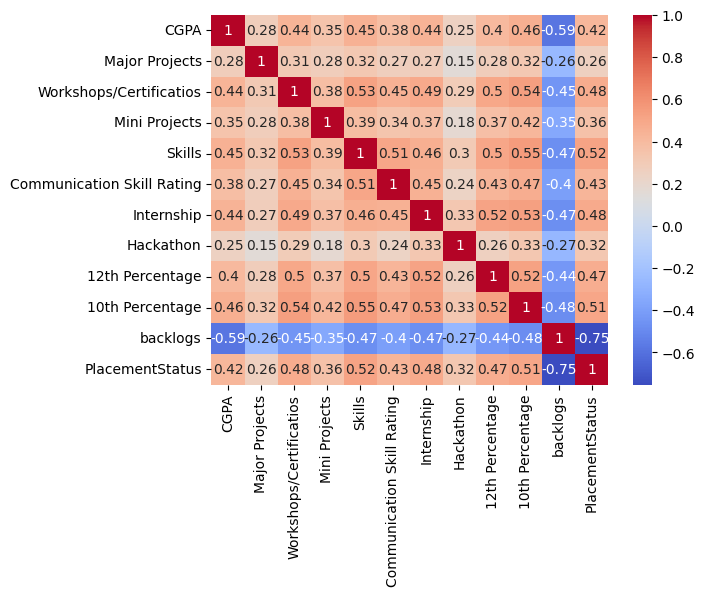

In [ ]:
placement_corr = placement.corr()
salary_corr = salary.corr()
sns.heatmap(placement_corr, annot=True, cmap='coolwarm')

plt.show()

<Axes: >

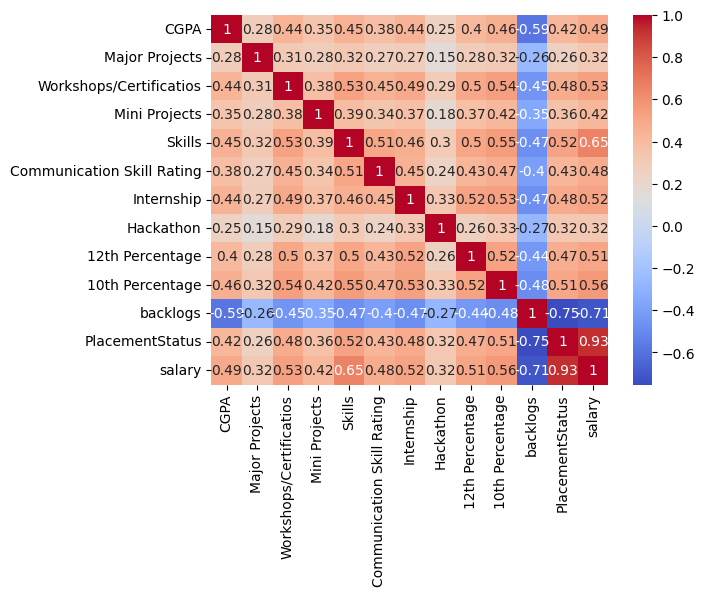

In [ ]:
sns.heatmap(salary_corr, annot=True, cmap='coolwarm')

In [ ]:
PX = placement.drop('PlacementStatus', axis=1)
Py = placement['PlacementStatus']
SX = salary.drop('PlacementStatus', axis=1)
Sy = salary['PlacementStatus']

In [ ]:
print("Placement Original Shape: " ,Counter(Py))
print("Salary Original Shape: " ,Counter(Sy))

Placement Original Shape:  Counter({0: 5803, 1: 4197})
Salary Original Shape:  Counter({0: 5803, 1: 4197})


We can infer from the above values, the datasert we have is skewed, in placement prediction, there is more data towards a student not getting placed, this may lead to a bias in the machine learning model and in the salary prediction part, there are more entries for high packages like 10LPA,10.5LPA (above 400) compared to 7.5LPA, 8.5LPA( around 50) this creates a bias in the model where students who are shown placed tend to show high packages which may/may not be realistic, to negate this while not removing any samples from the dataset(undersampling), we are going to use SMOTE,SMOTER from IMBLearn module to oversample the dataset with synthetic values so that we can reduce the inherent bias in the data


In [ ]:
smote = SMOTE(random_state = 42)
PX,Py = smote.fit_resample(PX,Py)
print("Placement Resampled Shape: " ,Counter(Py))

Placement Resampled Shape:  Counter({0: 5803, 1: 5803})


In [ ]:
salaryNotZero = salary[salary['salary'] != 0]
X = salaryNotZero.drop(columns=['salary']).values
y = salaryNotZero['salary'].values.reshape(-1, 1)

In [ ]:
scaler_X = StandardScaler().fit(X)
X_scaled = scaler_X.transform(X)
scaler_y = StandardScaler().fit(y)
y_scaled = scaler_y.transform(y)

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
input_dim = X_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
latent = layers.Dense(16, activation='relu')(encoded)
decoded = layers.Dense(32, activation='relu')(latent)
decoded = layers.Dense(64, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

# Prepare features X and target y
X = salaryNotZero.drop(columns=['salary']).values
y = salaryNotZero['salary'].values.reshape(-1, 1)

# Standardize features and target
scaler_X = StandardScaler().fit(X)
X_scaled = scaler_X.transform(X)

scaler_y = StandardScaler().fit(y)
y_scaled = scaler_y.transform(y)

# Build Autoencoder for features
input_dim = X_scaled.shape[1]
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
latent = layers.Dense(16, activation='relu')(encoded)
decoded = layers.Dense(32, activation='relu')(latent)
decoded = layers.Dense(64, activation='relu')(decoded)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)

# Compile autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=64, validation_split=0.1, verbose=2)

# Encode features to latent space
encoder = models.Model(inputs=input_layer, outputs=latent)
latent_repr = encoder.predict(X_scaled)

# Identify minority samples (lowest 25% salary as example)
minority_indices = np.where(y.flatten() < np.percentile(y, 25))[0]
latent_minority = latent_repr[minority_indices]

# Generate synthetic latent samples by adding noise
num_synthetic = len(minority_indices)
noise = np.random.normal(0, 0.1, size=latent_minority.shape)
synthetic_latent = latent_minority + noise

# Build decoder model from last decoder layers
decoder_input = layers.Input(shape=(16,))
x = autoencoder.layers[-3](decoder_input)
x = autoencoder.layers[-2](x)
decoder_output = autoencoder.layers[-1](x)
decoder = models.Model(inputs=decoder_input, outputs=decoder_output)

# Decode synthetic samples back to feature space
synthetic_X_scaled = decoder.predict(synthetic_latent)
synthetic_X = scaler_X.inverse_transform(synthetic_X_scaled)

# For synthetic targets, assign mean salary of minority group (can be replaced with model prediction)
synthetic_y = np.repeat(np.mean(y[minority_indices]), num_synthetic).reshape(-1, 1)

# Combine original data with synthetic samples
SX = np.vstack([X, synthetic_X])
Sy = np.vstack([y, synthetic_y])

print(f"Original data shape: {X.shape}, {y.shape}")
print(f"Augmented data shape: {SX.shape}, {Sy.shape}")

# X_augmented, y_augmented now ready for regression model training


Epoch 1/50
60/60 - 7s - 110ms/step - loss: 0.7607 - val_loss: 0.5047
Epoch 2/50
60/60 - 0s - 8ms/step - loss: 0.3945 - val_loss: 0.2813
Epoch 3/50
60/60 - 0s - 7ms/step - loss: 0.2320 - val_loss: 0.1671
Epoch 4/50
60/60 - 1s - 11ms/step - loss: 0.1462 - val_loss: 0.1210
Epoch 5/50
60/60 - 1s - 11ms/step - loss: 0.0997 - val_loss: 0.0846
Epoch 6/50
60/60 - 1s - 14ms/step - loss: 0.0695 - val_loss: 0.0528
Epoch 7/50
60/60 - 1s - 16ms/step - loss: 0.0388 - val_loss: 0.0261
Epoch 8/50
60/60 - 1s - 14ms/step - loss: 0.0217 - val_loss: 0.0184
Epoch 9/50
60/60 - 1s - 12ms/step - loss: 0.0157 - val_loss: 0.0187
Epoch 10/50
60/60 - 0s - 3ms/step - loss: 0.0139 - val_loss: 0.0151
Epoch 11/50
60/60 - 0s - 3ms/step - loss: 0.0121 - val_loss: 0.0130
Epoch 12/50
60/60 - 0s - 3ms/step - loss: 0.0097 - val_loss: 0.0110
Epoch 13/50
60/60 - 0s - 3ms/step - loss: 0.0090 - val_loss: 0.0091
Epoch 14/50
60/60 - 0s - 3ms/step - loss: 0.0075 - val_loss: 0.0149
Epoch 15/50
60/60 - 0s - 4ms/step - loss: 0.0079 

In [ ]:
PX_train , PX_test ,Py_train,Py_test = train_test_split(PX,Py,test_size= 0.2,random_state=42)
SX_train , SX_test ,Sy_train,Sy_test = train_test_split(SX,Sy,test_size = 0.2,random_state = 42)

In [ ]:
scaler = StandardScaler()
PX_train = scaler.fit_transform(PX_train)
PX_test = scaler.transform(PX_test)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    model.fit(PX_train, Py_train)
    preds = model.predict(PX_test)
    acc = accuracy_score(Py_test, preds)
    print(f'\n{name} Accuracy: {acc:.2f}')
    print(classification_report(Py_test, preds))
    results[name] = acc


Logistic Regression Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      1160
           1       0.91      0.95      0.93      1162

    accuracy                           0.93      2322
   macro avg       0.93      0.93      0.93      2322
weighted avg       0.93      0.93      0.93      2322


Decision Tree Accuracy: 0.93
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1160
           1       0.92      0.93      0.93      1162

    accuracy                           0.93      2322
   macro avg       0.93      0.93      0.93      2322
weighted avg       0.93      0.93      0.93      2322


Random Forest Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1160
           1       0.95      0.95      0.95      1162

    accuracy                           0.95      2322
   macro avg       0.95      0.9

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:52:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'XGBoost': XGBRegressor()
}

results = {}

for name, model in models.items():
    model.fit(SX_train, Sy_train)
    preds = model.predict(SX_test)
    rmse = np.sqrt(mean_squared_error(Sy_test, preds))
    r2 = r2_score(Sy_test, preds)
    print(f'\n{name}')
    print(f'RMSE: {rmse:.2f}, R²: {r2:.2f}')
    results[name] = {'RMSE': rmse, 'R2': r2}


Linear Regression
RMSE: 127266.47, R²: 0.81

Ridge
RMSE: 126913.26, R²: 0.81

Lasso
RMSE: 127253.45, R²: 0.81

ElasticNet
RMSE: 163352.35, R²: 0.69

Decision Tree
RMSE: 99132.09, R²: 0.89


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest
RMSE: 74625.12, R²: 0.94


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?



Gradient Boosting
RMSE: 71640.46, R²: 0.94

AdaBoost
RMSE: 81169.74, R²: 0.92


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



SVR
RMSE: 303909.90, R²: -0.07

KNN
RMSE: 170506.44, R²: 0.66

XGBoost
RMSE: 78111.18, R²: 0.93


We can observe that In classification model,XGBoost gives highest accuracy and in regression model, Gradient Boosting has high R squared value. So we are using XGBoost for predicting whether student will be placed or not and Gradient Boosting to see how much package will he get


In [ ]:
import pickle
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
PX_train = scaler.fit_transform(PX_train)
PX_test = scaler.transform(PX_test)

In [ ]:
placementModel = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
placementModel.fit(PX_train, Py_train)

# Save model as pickle
with open('placement_model.pkl', 'wb') as f:
    pickle.dump(placementModel, f)
# Optionally save the scaler as well
with open('placement_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:52:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
scaler = StandardScaler()
PX_train = scaler.fit_transform(SX_train)
PX_test = scaler.transform(SX_test)

In [ ]:
salaryModel = GradientBoostingRegressor()
salaryModel.fit(SX_train, Sy_train)

# Save model as pickle
with open('salary_model.pkl', 'wb') as f:
    pickle.dump(salaryModel, f)
# Optionally save the scaler as well
with open('salary_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [ ]:
# Step 1: Create new data
new_student_features = {
    'CGPA': [8.9],
    'Major Projects': [0],
    'Workshops/Certificatios': [3],
    'Mini Projects': [2],
    'Skills': [9],
    'Communication Skill Rating': [4.0],
    'Internship': ['Yes'],  # Use original categorical value for Label Encoding
    'Hackathon': ['Yes'], # Use original categorical value for Label Encoding
    '12th Percentage': [78],
    '10th Percentage': [82],
    'backlogs': [0]
}
new_student_data = pd.DataFrame(new_student_features)

# Step 2: Load models and scalers
import pickle

with open('placement_model.pkl', 'rb') as f:
    placementModel = pickle.load(f)

with open('placement_scaler.pkl', 'rb') as f:
    placement_scaler = pickle.load(f)

with open('salary_model.pkl', 'rb') as f:
    salaryModel = pickle.load(f)

with open('salary_scaler.pkl', 'rb') as f:
    salary_scaler = pickle.load(f)

# Step 3: Preprocess new data
# Apply Label Encoding to the new data for categorical features
# Need to use the same LabelEncoder fitted on the training data if possible,
# but since we don't have it saved, we'll refit on the original data columns
# This is a simplification; ideally, the fitted encoder should be saved and loaded
le = LabelEncoder()
new_student_data['Internship'] = le.fit_transform(new_student_data['Internship'])
new_student_data['Hackathon'] = le.fit_transform(new_student_data['Hackathon'])


# Scale the features using the placement scaler
new_student_scaled = placement_scaler.transform(new_student_data)

# Step 4: Predict placement status
placement_prediction = placementModel.predict(new_student_scaled)

# Step 5: Predict salary if placed
if placement_prediction[0] == 1: # Assuming 1 represents 'Placed' based on previous encoding
    print("Predicted Placement Status: Placed")

    # Scale the new data using the salary scaler
    # Need to ensure the columns are in the same order as the training data for the salary model
    # Assuming the order is the same as new_student_data columns
    new_student_scaled_salary = salary_scaler.transform(new_student_data)

    salary_prediction_scaled = salaryModel.predict(new_student_scaled_salary)

    # Inverse transform the salary prediction to get the actual salary value
    salary_prediction = salary_scaler.inverse_transform(salary_prediction_scaled.reshape(-1, 1))

    # Step 6: Display results
    print(f"Predicted Salary: {salary_prediction[0][0]:,.2f}")
else:
    # Step 6: Display results
    print("Predicted Placement Status: Not Placed")

Predicted Placement Status: Not Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
# Step 1: Create new data 8.9	0	3	2	9	4.0	1	1	78	82	0	1
new_student_features = {
    'CGPA': [8.9],
    'Major Projects': [0],
    'Workshops/Certificatios': [3],
    'Mini Projects': [2],
    'Skills': [9],
    'Communication Skill Rating': [4.0],
    'Internship': ['Yes'],  # Use original categorical value for Label Encoding
    'Hackathon': ['Yes'], # Use original categorical value for Label Encoding
    '12th Percentage': [78],
    '10th Percentage': [82],
    'backlogs': [0]
}
new_student_data = pd.DataFrame(new_student_features)

# Step 2: Load models and scalers
import pickle

with open('placement_model.pkl', 'rb') as f:
    placementModel = pickle.load(f)

with open('placement_scaler.pkl', 'rb') as f:
    placement_scaler = pickle.load(f)

with open('salary_model.pkl', 'rb') as f:
    salaryModel = pickle.load(f)

with open('salary_scaler.pkl', 'rb') as f:
    salary_scaler = pickle.load(f)

# Step 3: Preprocess new data
# Apply Label Encoding to the new data for categorical features
# Need to use the same LabelEncoder fitted on the training data if possible,
# but since we don't have it saved, we'll refit on the original data columns
# This is a simplification; ideally, the fitted encoder should be saved and loaded
le = LabelEncoder()
new_student_data['Internship'] = le.fit_transform(new_student_data['Internship'])
new_student_data['Hackathon'] = le.fit_transform(new_student_data['Hackathon'])


# Scale the features using the placement scaler
new_student_scaled = placement_scaler.transform(new_student_data)

# Step 4: Predict placement status
placement_prediction = placementModel.predict(new_student_scaled)

# Step 5: Predict salary if placed
if placement_prediction[0] == 1: # Assuming 1 represents 'Placed' based on previous encoding
    print("Predicted Placement Status: Placed")

    # Scale the new data using the salary scaler
    # Need to ensure the columns are in the same order as the training data for the salary model
    # Assuming the order is the same as new_student_data columns
    new_student_scaled_salary = salary_scaler.transform(new_student_data)

    salary_prediction_scaled = salaryModel.predict(new_student_scaled_salary)

    # Inverse transform the salary prediction to get the actual salary value
    salary_prediction = salary_scaler.inverse_transform(salary_prediction_scaled.reshape(-1, 1))

    # Step 6: Display results
    print(f"Predicted Salary: {salary_prediction[0][0]:,.2f}")
else:
    # Step 6: Display results
    print("Predicted Placement Status: Not Placed")

Predicted Placement Status: Not Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
